### Functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def return_omega_j(j, E, J, l, mu):
    omega_j = j**2*np.pi**2/l**2*(E*J/mu)**(1/2)
    return omega_j

def get_v(x: np.ndarray,
          t: np.ndarray,
          j_end: int,
          alpha: float,
          omega: float,
          v0: float,
          l: float,
          E: float,
          J: float,
          mu: float,
          omega_d: float = 0,
          return_contr: bool = 0):

    # x, t: 1D arrays
    gridx, gridt = np.meshgrid(x, t, indexing='ij')

    v = np.zeros_like(gridx)
    beta = omega_d / return_omega_j(1, E, J, l, mu)

    v_contr = []
    for j in range(1, j_end):
        omega_j = return_omega_j(j, E, J, l, mu)
        v_j = np.sin(j * np.pi * gridx/l)
        if j == alpha:
            if beta != 0:
                v_j *= (np.exp(-omega_d*gridt)*np.sin(
                        j*omega*gridt)- j**2/beta * np.cos(j*omega*gridt) * (1-
                        np.exp(-omega_d*gridt)))
            else:
                v_j *= (np.sin(j * omega * gridt) - 
                        j * omega * gridt * np.cos(j * omega * gridt))
            v_j *= 1/(2*j**4)
            plt.figure()
            plt.plot(t, v_j[v_j.shape[0]//2, :])
            plt.title(f'alpha = {j}')
            plt.show()
        else:
            v_j *= (np.sin(omega * j * gridt) - 
                    alpha/j * np.exp(-omega_d * gridt) * np.sin(omega_j * gridt))
            v_j *= 1/(j**2*(j**2-alpha**2))

        v += v_j
        v_contr.append(np.mean(v_j[v_j.shape[0]//2, :]))

    v *= v0
    v_contr = np.array(v_contr)
    if return_contr:
        return v, v_contr
    else:
        return v

def get_M(x: np.ndarray,
          t: np.ndarray,
          j_end: int,
          alpha: float,
          omega: float,
          M0: float,
          l: float,
          E: float,
          J: float,
          mu: float,
          omega_d: float = 0):

    gridx, gridt = np.meshgrid(x, t, indexing='ij')

    M = np.zeros_like(gridx)
    beta = omega_d / return_omega_j(1, E, J, l, mu)

    for j in range(1, j_end):
        omega_j = return_omega_j(j, E, J, l, mu)
        M_j = np.sin(j * np.pi * gridx/l)
        if alpha == j:
            if beta != 0:
                M_j *= 1/(np.pi**2*j**2)*(np.exp(-omega_d*gridt)*np.sin(
                        j*omega*gridt)-j**2/beta*np.cos(j*omega*gridt)*(1-
                        np.exp(-omega_d*gridt)))
            else:
                M_j *= 1/(np.pi**2*j**2)*(np.sin(j*omega*gridt)-
                        j*omega*gridt*np.cos(j*omega*gridt))
            M_j *= 4*M0
        else:
            M_j *= (np.sin(omega * j * gridt) 
                    - alpha/j * np.exp(-omega_d * gridt) * np.sin(omega_j * gridt))
            M_j *= 1/(j**2*(1-alpha**2/j**2))
            M_j *= 8/(np.pi**2)
            M_j *= M0

        M += M_j

    return M

def get_v_dot(x: np.ndarray,
          t: np.ndarray,
          j_end: int,
          alpha: float,
          omega: float,
          v0: float,
          l: float,
          E: float,
          J: float,
          mu: float,
          omega_d: float = 0):

    # x, t: 1D arrays
    gridx, gridt = np.meshgrid(x, t, indexing='ij')

    v = np.zeros_like(gridx)
    beta = omega_d / return_omega_j(1, E, J, l, mu)

    for j in range(1, j_end):
        omega_j = return_omega_j(j, E, J, l, mu)
        v_j = np.sin(j * np.pi * gridx/l)
        if j == alpha:
            if beta != 0:
                pass
            else:
                v_j *= (j*omega*np.cos(j * omega * gridt) - 
                        (j * omega * np.cos(j * omega * gridt) -
                        j**2*omega**2*gridt*np.sin(j * omega * gridt)))
            v_j *= 1/(2*j**4)
            plt.figure()
            plt.plot(t, v_j[v_j.shape[0]//2, :])
            plt.title(f'alpha = {j}')
            plt.show()
        else:
            v_j *= (j*omega*np.cos(omega * j * gridt) - 
                    alpha/j * (-omega_d *np.exp(-omega_d * gridt) * np.sin(omega_j * gridt) +
                    np.exp(-omega_d * gridt) * omega_j * np.cos(omega_j * gridt)))
            v_j *= 1/(j**2*(j**2-alpha**2))

        v += v_j

    v *= v0

    return v

### Midspan BM

alpha = 1.06e+00


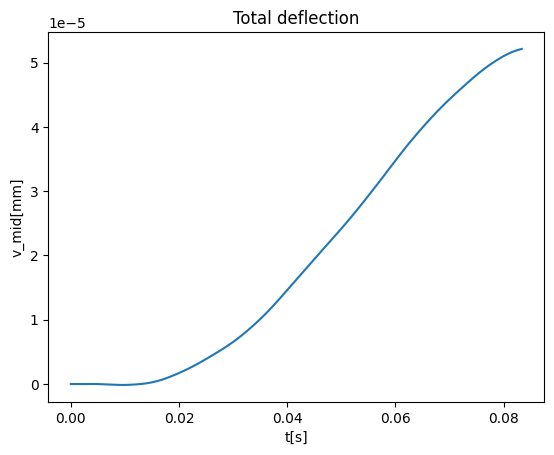

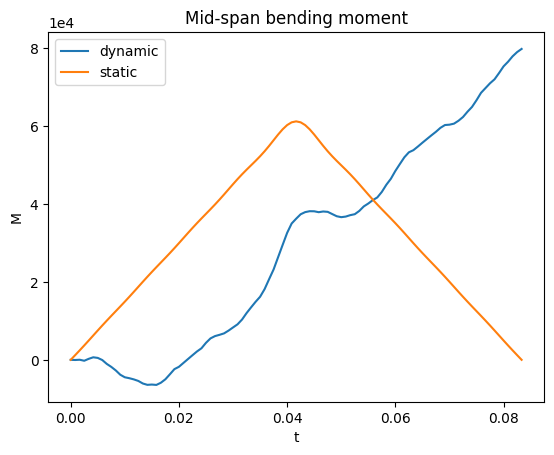

In [3]:
l = 25
c = 300
T = l/c
P = 1e4
E = 3.5e10
J = 3.8349*0.7
mu = 18358
j_end = 20
damp_ratio = 0

nx = 101
nt = 101

omega = np.pi * c/l
v0 = 2*P*l**3/(np.pi**4*E*J)
M0 = P*l/4
omega1 = return_omega_j(1, E, J, l, mu)
alpha = omega/omega1

omega_d = 0

x = np.linspace(0, l, nx)
t = np.linspace(0, T, nt)
dx = l/(nx-1)
dt = T/(nt-1)

v, v_contr = get_v(x, t, j_end, alpha, omega, v0, l, E, J, mu, omega_d, True)
v_static = get_v(x, t, j_end, 0, omega, v0, l, E, J, mu, omega_d, False)
print(f"alpha = {alpha:.2e}")

#Plot midspan displacement in time
v_mid = v[v.shape[0]//2, :]

plt.figure()
plt.plot(t, v_mid)
plt.xlabel('t[s]')
plt.ylabel('v_mid[mm]')
plt.title('Total deflection')
plt.show()

M = get_M(x, t, j_end, alpha, omega, M0, l, E, J, mu, omega_d)
M_mid = M[M.shape[0]//2, :]
M_static = get_M(x, t, j_end, 0, omega, M0, l, E, J, mu, omega_d)
plt.figure()
plt.plot(t, M_mid, label='dynamic')
plt.ticklabel_format(axis='y', scilimits=(0,0))
plt.plot(t, M_static[M_static.shape[0]//2,:], label='static')
plt.xlabel('t')
plt.ylabel('M')
plt.title('Mid-span bending moment')
plt.legend()
plt.show()

### Sweep alphas

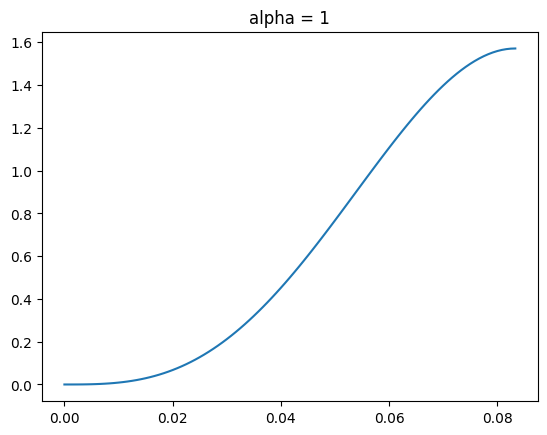

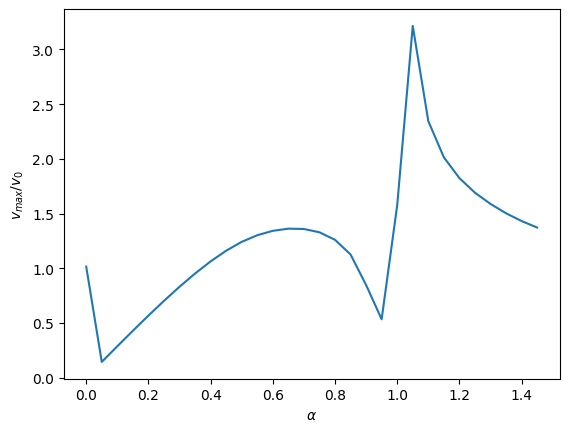

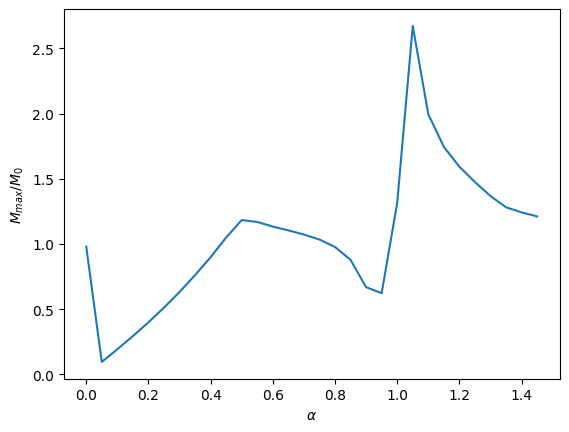

In [4]:
Ms = []
vs = []
alpha_arr = np.arange(0, 1.5, 0.05)
omega_beam = omega
for alpha in alpha_arr:
    omega_sweep = omega_beam * alpha
    if alpha == 0:
        # use omega, otherwise solution == 0
        v_alpha = get_v(x, t, j_end, alpha, omega, v0, l, E, J, mu, omega_d)/v0
        M_alpha = get_M(x, t, j_end, alpha, omega, M0, l, E, J, mu, omega_d)/M0
    else:
        v_alpha = get_v(x, t, j_end, alpha, omega_sweep, v0, l, E, J, mu, omega_d)/v0
        M_alpha = get_M(x, t, j_end, alpha, omega_sweep, M0, l, E, J, mu, omega_d)/M0

    M_max = np.max(M_alpha[M_alpha.shape[0]//2, :])
    v_max = np.max(v_alpha[v_alpha.shape[0]//2, :])
    Ms.append(M_max)
    vs.append(v_max)

Ms = np.array(Ms)
vs = np.array(vs)

plt.figure()
plt.plot(alpha_arr, vs)
plt.ticklabel_format(axis='y', scilimits=(0,0))
plt.xlabel(r'$\alpha$')
plt.ylabel(r'$v_{max}/v_0$')
plt.show()

plt.figure()
plt.plot(alpha_arr, Ms)
plt.ticklabel_format(axis='y', scilimits=(0,0))
plt.xlabel(r'$\alpha$')
plt.ylabel(r'$M_{max}/M_0$')
plt.show()

# Add free response

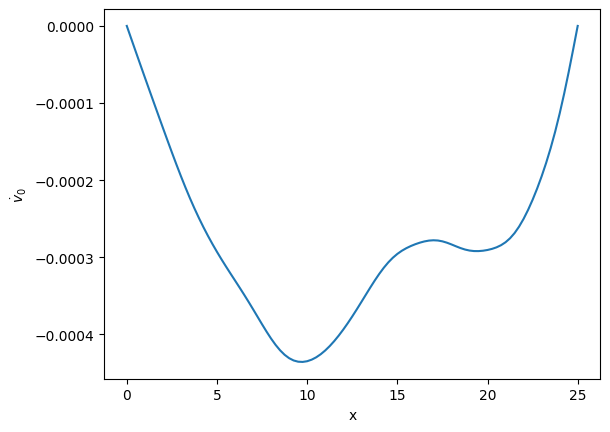

In [ ]:
v_dot_end = get_v_dot(x, t[-1], j_end, alpha, omega, v0, l, E, J, mu, omega_d).reshape(-1,1)
v_end = v[:, -1].reshape(-1,1)

plt.figure()
plt.plot(x, v_dot_end, label='v_dot_end')
plt.xlabel('x')
plt.ylabel(r'$\dot{v}_0$')
plt.show()

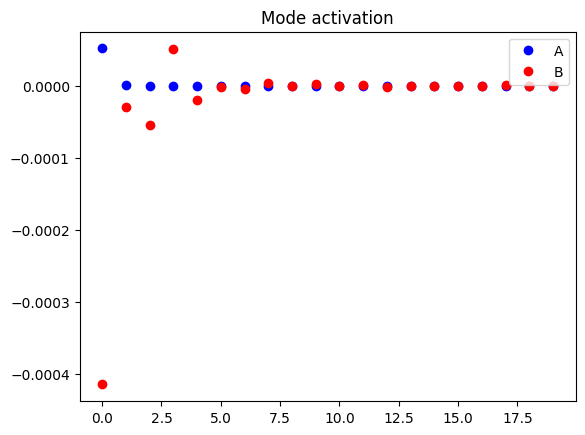

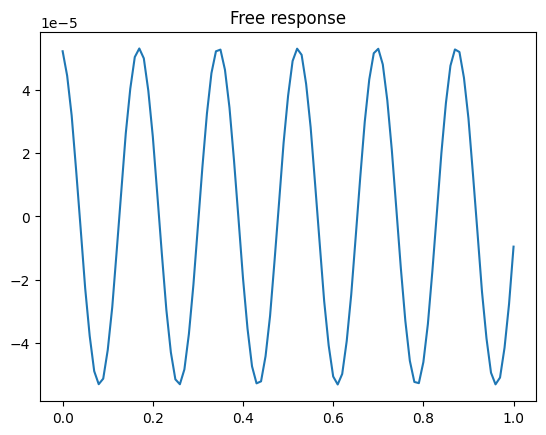

In [ ]:
def get_free_response(t: np.ndarray, A: np.ndarray, B: np.ndarray):
    gridx, gridt = np.meshgrid(x, t, indexing='ij')
    v = np.zeros((len(x), len(t)))
    for j in range(0, A.shape[0]):
        omega_j = return_omega_j(j + 1, E, J, l, mu)
        vj = A[j] * np.cos(omega_j * gridt) + B[j] * np.sin(omega_j * gridt)
        vj *= np.sin((j + 1) * np.pi * gridx/l)
        v += vj
    return v

A = np.zeros(j_end)
B = np.zeros(j_end)

phi = np.zeros((len(x), j_end))  # Initialize matrix

for j in range(1, j_end + 1):
    phi[:, j - 1] = np.sin(j * np.pi * x / l)

A = np.trapezoid(v_end * phi, x, axis=0)
B = np.trapezoid(v_dot_end * phi, x, axis=0)

A *= 2/l
B *= 2/l

for i in range(1, B.shape[0] + 1):
    B[i - 1] *= 1/return_omega_j(i, E, J, l, mu)

plt.figure()
plt.title('Mode activation')
plt.plot(np.arange(0, j_end), A, 'bo', label='A')
plt.plot(np.arange(0, j_end), B, 'ro', label='B')
plt.legend()
plt.show()


t = np.linspace(0, 1, nt)
dt = t[1] - t[0]
v_free = get_free_response(t, A, B)
v_free_mid = v_free[v_free.shape[0]//2, :]
idx_min = np.argmin(v_free_mid)
t_min = idx_min * dt
plt.figure()
plt.ticklabel_format(axis='y', scilimits=(0,0))
plt.title('Free response')
plt.plot(t, v_free_mid)
plt.show()